In [3]:
!pip install opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 10.4 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np


Mounted at /content/drive


In [ ]:
oyuncu_yolu = '/content/drive/MyDrive/Dataset/oyuncular/'
test_yolu = '/content/drive/MyDrive/Dataset/test'

face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

faces = []
ids = []
oyuncu_isimleri = {}

for etiket, oyuncu in enumerate(os.listdir(oyuncu_yolu)):
    oyuncu_isimleri[etiket] = oyuncu
    oyuncu_klasoru = os.path.join(oyuncu_yolu, oyuncu)
    for resim in os.listdir(oyuncu_klasoru):
        resim_yolu = os.path.join(oyuncu_klasoru, resim)
        img = cv2.imread(resim_yolu)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        yuzler = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=10, minSize=(80,80))
        if len(yuzler) == 1:
            (x, y, w, h) = yuzler[0]
            roi_gray = gray[y:y+h, x:x+w]
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            roi_gray = clahe.apply(roi_gray)
            roi_gray = cv2.resize(roi_gray, (100,100))
            faces.append(roi_gray)
            ids.append(etiket)

recognize = cv2.face.LBPHFaceRecognizer_create(radius=1,neighbors=8,grid_x=8,grid_y=8,threshold=200.0)
recognize.train(faces,np.array(ids))


In [11]:
img = cv2.imread(test_yolu+'/test5.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
face = face_detector.detectMultiScale(gray,scaleFactor=1.1, minNeighbors=5,minSize=(40,40))
print(len(face))

for(x,y,w,h) in face:
  roi_gray = gray[y:y+h,x:x+w]
  if roi_gray.size == 0:
    continue
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
  image = clahe.apply(roi_gray)
  roi_img = cv2.resize(image, (100, 100))
  etiket, skor = recognize.predict(roi_img)
  if skor > 100:
    isim = "kayitli degil"
  else:
    isim = oyuncu_isimleri[etiket]
  cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),4)
  cv2.putText(img,f"{isim} ({skor: .2f})",(x,y-10),cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,255),2)


1


(np.float64(-0.5), np.float64(1279.5), np.float64(1518.5), np.float64(-0.5))

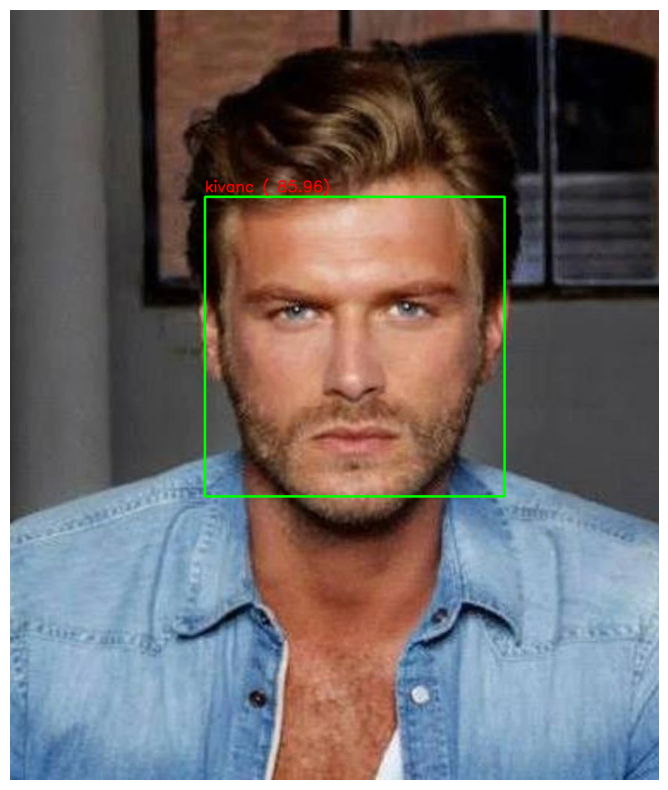

In [12]:
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img_rgb)
plt.axis('off')